 # **Описание**

 Датасет включает 10 000 синтетических записей из 20 стран с данными о кофеиновом профиле, сне, демографии и здоровье (Индекс Массы Тела (ИМТ), Частота Сердечных Сокращений (ЧСС), стресс, активность, вредные привычки), что позволяет исследовать взаимосвязи между кофе и образом жизни.

## **Цель**

Провести комплексный EDA для выявления статистически значимых взаимосвязей между уровнем потребления кофе и ключевыми метриками здоровья

## **Структура данных**

- ID — уникальный идентификатор записи.

- Age — возраст участника.

- Gender — пол участника.

- Country — страна проживания.

- Coffee_Intake — ежедневное потребление кофе в чашках.

- Caffeine_mg — примерное суточное потребление кофеина в миллиграммах.

- Sleep_Hours — средняя продолжительность сна в сутки, в часах.

- Sleep_Quality — оценка качества сна.

- BMI — индекс массы тела.

- Heart_Rate — частота сердечных сокращений в состоянии покоя.

- Stress_Level — уровень стресса.

- Physical_Activity_Hours — количество часов физической активности в неделю.

- Health_Issues — наличие и степень проблем со здоровьем.

- Occupation — сфера занятости или профессия.

- Smoking — наличие привычки курения: 0 — нет, 1 — да.

- Alcohol_Consumption — употребление алкоголя: 0 — нет, 1 — да.

## **План работы**

### ЗАГРУЗКА И ЗНАКОМСТВО С ДАННЫМИ


1. Импортировать необходимые библиотеки

2. Загрузить датасет (pandas)

3. Вывести первые/последние 5 строк для знакомства с данными

4. Использовать df.info() для проверки типов данных и пропусков

5. Использовать df.describe() для базовых статистик числовых переменных

6. Проверить уникальные значения в категориальных колонках;

&nbsp;
### ПРЕДОБРАБОТКА ДАННЫХ


1. Приведение названий колонок к змеиному регистру (snake_case)
2. Обработка пропусков
3. Удаление бесполезных колонок
4. Проверка на дубликаты
5. Обработка аномалий (выбросов):

&nbsp;
### ОБОГАЩЕНИЕ ДАННЫХ

1. Создать целевую переменную Coffee_Drinker_Type
2. Создать возрастные группы Age_Group
3. Создать бинарный признак Stress_High
4. Создать категориальный признак BMI_Category по шкале ВОЗ

&nbsp;
### ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ (EDA)

1. Гистограммы распределения числовых переменных + выводы
2. Столбачтыедиаграммы категориальных переменных + выводы
3. Корреляции

&nbsp;
### ПРОВЕРКА ГИПОТЕЗ

1. **ГИПОТЕЗА: Влияние кофе на продолжительность сна**

    - H₀: Потребление кофе не влияет на продолжительность сна

    - H₁: Потребление кофе сокращает продолжительность сна



2. **ГИПОТЕЗА: Влияние кофе на частоту сердечных сокращений**

    - H₀: Кофе не влияет на частоту пульса

    - H₁: Кофе положительно коррелирует с пульсом


3. **ГИПОТЕЗА: Связь кофе с уровнем стресса**

    - H₀: Уровень стресса не зависит от потребления кофе

    - H₁: Уровень стресса связан с потреблением кофе


4. **ГИПОТЕЗА: Связь кофе с ИМТ**

    - H₀: Кофе не влияет на ИМТ (null-гипотеза)

    - H₁: Кофе влияет на ИМТ


&nbsp;
### ВЫВОДЫ

(как пример)

    - Какие связи обнаружены

    - Практическая значимость результатов

    - Ограничения исследования

# **Загрузка и знакомство с данными**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats as st

In [3]:
df = pd.read_csv('coffee_health.csv')

In [4]:
df.head()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10000 non-null  int64  
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  object 
 3   Country                  10000 non-null  object 
 4   Coffee_Intake            10000 non-null  float64
 5   Caffeine_mg              10000 non-null  float64
 6   Sleep_Hours              10000 non-null  float64
 7   Sleep_Quality            10000 non-null  object 
 8   BMI                      10000 non-null  float64
 9   Heart_Rate               10000 non-null  int64  
 10  Stress_Level             10000 non-null  object 
 11  Physical_Activity_Hours  10000 non-null  float64
 12  Health_Issues            4059 non-null   object 
 13  Occupation               10000 non-null  object 
 14  Smoking                

In [6]:
df.describe()

,ID,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Smoking,Alcohol_Consumption
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000
mean,5000.50000,34.949100,2.509230,238.411010,6.636220,23.986860,70.617800,7.48704,0.20040,0.300700
std,2886.89568,11.160939,1.450248,137.748815,1.222055,3.906411,9.822951,4.31518,0.40032,0.458585
min,1.00000,18.000000,0.000000,0.000000,3.000000,15.000000,50.000000,0.00000,0.00000,0.000000
25%,2500.75000,26.000000,1.500000,138.750000,5.800000,21.300000,64.000000,3.70000,0.00000,0.000000
50%,5000.50000,34.000000,2.500000,235.400000,6.600000,24.000000,71.000000,7.50000,0.00000,0.000000
75%,7500.25000,43.000000,3.500000,332.025000,7.500000,26.600000,77.000000,11.20000,0.00000,1.000000
max,10000.00000,80.000000,8.200000,780.300000,10.000000,38.200000,109.000000,15.00000,1.00000,1.000000


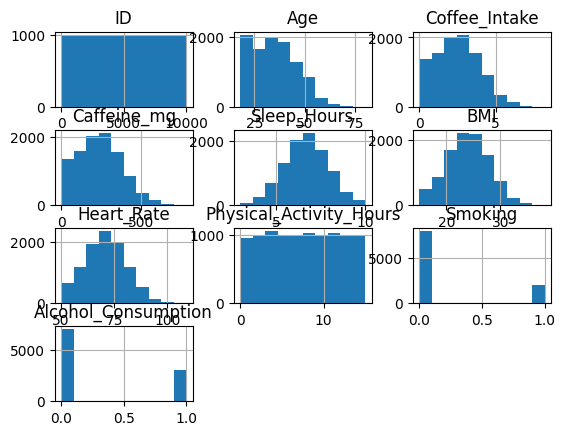

In [7]:
df.hist()
plt.show()

In [8]:
for col in df.select_dtypes(include=['object']).columns:
    print(f'Колонка: {col}')
    print(f'Уникальные значения: {df[col].unique()}')
    print(f'Количество уникальных: {df[col].nunique()}')
    print(f'Распределение:\n{df[col].value_counts()}')
    print('-' * 40)

Колонка: Gender
Уникальные значения: ['Male' 'Female' 'Other']
Количество уникальных: 3
Распределение:
Gender
Female    5001
Male      4773
Other      226
Name: count, dtype: int64
----------------------------------------
Колонка: Country
Уникальные значения: ['Germany' 'Brazil' 'Spain' 'Mexico' 'France' 'Canada' 'UK' 'Switzerland'
 'Netherlands' 'Italy' 'China' 'Japan' 'Belgium' 'Finland' 'Australia'
 'USA' 'Sweden' 'India' 'Norway' 'South Korea']
Количество уникальных: 20
Распределение:
Country
Canada         543
India          524
Norway         523
China          521
UK             519
Sweden         513
South Korea    512
Finland        510
Italy          509
Switzerland    500
France         499
Germany        497
Australia      497
Belgium        497
Netherlands    494
Spain          486
Mexico         483
Japan          469
Brazil         456
USA            448
Name: count, dtype: int64
----------------------------------------
Колонка: Sleep_Quality
Уникальные значения: ['Good'

# **Предобработка данных**

## Приведение колонок к единому формату

In [9]:
df.columns = (df.columns
              .str.replace(r'(?<=[a-z])(?=[A-Z])', '_', regex=True)
              .str.lower())

In [10]:
#df.head()

## Обработка пропусков

Пропуски были только в колонке "health_issues"

In [11]:
print(f'Процент пропуска: {df['health_issues'].isna().sum()/len(df['health_issues']) * 100:.0f}%')

Процент пропуска: 59%


## Удаление колонок

In [12]:
# Колонку "health_issues" удаляем, из-за большого кол-ва пропусков
df.drop('health_issues', axis=1, inplace=True)

In [13]:
if df.isna().sum().sum() == 0:
  print(f'Пропусков нет: {df.isna().sum().sum()}')
else:
  print(f'Проверить на пропуски: {df.isna().sum().sum()}')

Пропусков нет: 0


## Очистка колонки "Gender"

In [14]:
df = df.query('gender != "Other"').reset_index(drop=True)

In [15]:
df['gender'].unique()

array(['Male', 'Female'], dtype=object)

## Проверка на дубликаты

In [16]:
print(f'Полных дублей: {df.duplicated().sum()}')

Полных дублей: 0


### Проверка неявных дубликатов

In [17]:
# Проверка дубликатов по ключевым колонкам
key_cols = ['age', 'gender', 'bmi', 'sleep_hours']  # или другие
duplicates_partial = df.duplicated(subset=key_cols).sum()
print(f'Частичных дубликатов: {duplicates_partial}')

df[df.duplicated(subset=key_cols, keep=False)].sort_values(by=key_cols).head(10)

Частичных дубликатов: 135


,id,age,gender,country,coffee_intake,caffeine_mg,sleep_hours,sleep_quality,bmi,heart_rate,stress_level,physical_activity_hours,occupation,smoking,alcohol_consumption
8159,8345,18,Female,USA,3.5,331.9,5.7,Fair,15.0,60,Medium,13.0,Healthcare,0,1
8291,8480,18,Female,Spain,4.1,385.0,5.7,Fair,15.0,70,Medium,5.1,Student,0,0
5245,5357,18,Female,Mexico,0.4,37.3,6.1,Good,17.8,79,Low,2.2,Other,0,0
5826,5949,18,Female,USA,3.3,315.8,6.1,Good,17.8,77,Low,8.8,Service,0,0
3182,3250,18,Female,Germany,2.0,188.8,6.9,Good,18.4,85,Low,7.6,Office,0,1
3631,3714,18,Female,South Korea,1.5,144.2,6.9,Good,18.4,62,Low,8.9,Healthcare,0,1
3827,3915,18,Female,Netherlands,1.3,122.7,6.2,Good,18.9,84,Low,5.7,Other,0,0
6981,7141,18,Female,Norway,1.2,114.5,6.2,Good,18.9,50,Low,10.8,Other,0,0
3089,3156,18,Female,USA,2.5,234.5,5.6,Fair,20.3,58,Medium,14.9,Office,0,1
3472,3552,18,Female,India,1.6,153.8,5.6,Fair,20.3,73,Medium,7.8,Student,0,1


In [18]:
# Проверка уникальности ID
print(f'Всего записей: {len(df)}')
print(f'Уникальных ID: {df['id'].nunique()}')
print(f'Повторов ID: {len(df) - df['id'].nunique()}')

# Посмотреть повторы ID
duplicate_ids = df[df['id'].duplicated(keep=False)]
print(duplicate_ids.sort_values(by='id').head(10))

Всего записей: 9774
Уникальных ID: 9774
Повторов ID: 0
Empty DataFrame
Columns: [id, age, gender, country, coffee_intake, caffeine_mg, sleep_hours, sleep_quality, bmi, heart_rate, stress_level, physical_activity_hours, occupation, smoking, alcohol_consumption]
Index: []


## Обработка аномалий

(проверка идет по количественным колонкам: age, coffee_intake, sleep_hours, heart_rate, bmi)

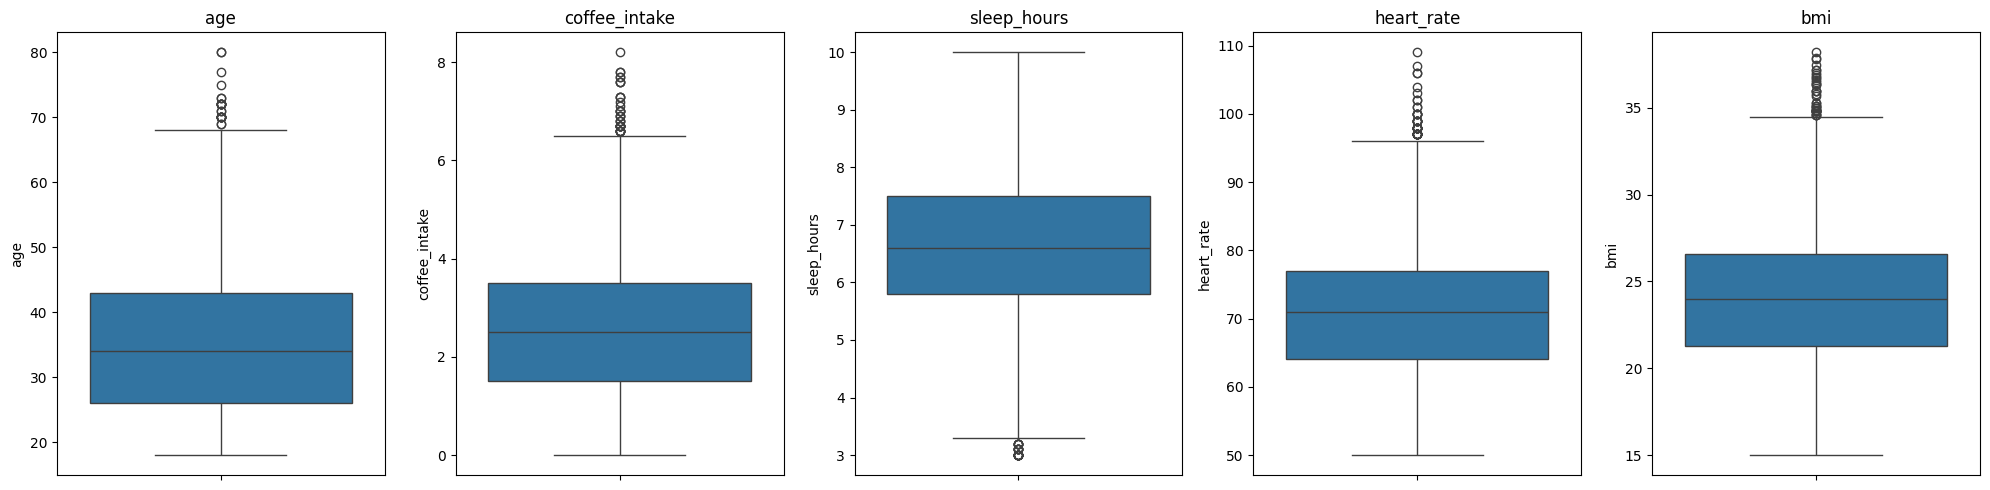

In [19]:
# Все числовые колонки в одном ряду
numeric_cols = ['age', 'coffee_intake', 'sleep_hours', 'heart_rate', 'bmi']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [20]:
# Функция для подсчёта аномалий
def count_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Проверка всех числовых колонок
numeric_cols = ['age', 'coffee_intake', 'sleep_hours', 'heart_rate', 'bmi']

for col in numeric_cols:
    count, lower, upper = count_outliers_iqr(df, col)
    print(f'{col}: {count} аномалий (границы: {lower:.2f} - {upper:.2f})')

age: 25 аномалий (границы: 0.50 - 68.50)
coffee_intake: 38 аномалий (границы: -1.50 - 6.50)
sleep_hours: 26 аномалий (границы: 3.25 - 10.05)
heart_rate: 47 аномалий (границы: 44.50 - 96.50)
bmi: 39 аномалий (границы: 13.35 - 34.55)


In [21]:
df[['age', 'coffee_intake', 'sleep_hours', 'heart_rate', 'bmi']].describe()

,age,coffee_intake,sleep_hours,heart_rate,bmi
count,9774.000000,9774.000000,9774.000000,9774.000000,9774.000000
mean,34.959382,2.509679,6.637211,70.629016,23.989196
std,11.170478,1.448631,1.222802,9.817483,3.908612
min,18.000000,0.000000,3.000000,50.000000,15.000000
25%,26.000000,1.500000,5.800000,64.000000,21.300000
50%,34.000000,2.500000,6.600000,71.000000,24.000000
75%,43.000000,3.500000,7.500000,77.000000,26.600000
max,80.000000,8.200000,10.000000,109.000000,38.200000


С помощью метода межквартильного размаха были проверены все числовые переменные. Выявленные выбросы составляют от 0.25% до 0.5% от общего объёма данных. При визуальном анализе распределений и проверке физиологических границ (возраст 18-100, пульс 40-120, ИМТ 10-50) установлено, что все значения находятся в реалистичных пределах. Аномалии представляют собой естественные крайние значения (пожилой возраст, высокое потребление кофе, низкая продолжительность сна, учащённый пульс, ожирение) и не являются ошибками ввода. Принято решение не удалять аномалии, чтобы сохранить репрезентативность выборки.

**Метод межквартильного размаха показывает выбросы, но не все выбросы = ошибки.**

# Обогащение данных

## Создание целевой переменной "coffee_drinker_type"

In [22]:
df['coffee_drinker_type'] = pd.qcut(
    df['coffee_intake'],
    q = 3,
    labels=["Low","Moderate","High"]
)

In [23]:
# проверка работы функции qcut, на равномерное распределение по категориям
print(df.groupby('coffee_drinker_type', observed=True)['coffee_intake'].describe())

                      count      mean       std  min  25%   50%  75%  max
coffee_drinker_type                                                      
Low                  3322.0  0.943317  0.609055  0.0  0.4  1.05  1.5  1.8
Moderate             3281.0  2.504602  0.367822  1.9  2.2  2.50  2.8  3.1
High                 3171.0  4.155881  0.811852  3.2  3.5  4.00  4.6  8.2


## Создание колонки с возрастными группами "age_group" 18-30, 31-45, 46-60, 60+

In [24]:
df['age_group'] = pd.cut(
    df['age'],
    bins = [18, 31, 46, 61, 100],
    labels=['18-30','31-45','46-60','60+'],
    right=False

)

In [25]:
#df.head()

## Создание колонки с бинарным признаком уровня стресса "stress_high" на основе колонки "stress_level"

In [26]:
def stress_group (lvl):
  if lvl == 'High':
    return 1
  else:
    return 0

In [27]:
df['stress_high'] = df['stress_level'].apply(stress_group)

In [28]:
df.head()

,id,age,gender,country,coffee_intake,caffeine_mg,sleep_hours,sleep_quality,bmi,heart_rate,stress_level,physical_activity_hours,occupation,smoking,alcohol_consumption,coffee_drinker_type,age_group,stress_high
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,Other,0,0,High,31-45,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,Service,0,0,Low,31-45,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Office,0,0,High,31-45,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Other,0,0,Moderate,46-60,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Student,0,1,Moderate,31-45,0


In [29]:
# проверка работы функции
df['stress_high'].value_counts()

,count
stress_high,
0,8834
1,940


In [30]:
df.groupby('stress_level')['stress_high'].value_counts()

,,count
stress_level,stress_high,
High,1,940
Low,0,6828
Medium,0,2006


## Создание категориальный переменной bmi_category по шкале ВОЗ
Недостаточный вес: < 18.5
Норма: 18.5 – 24.9
Избыточный вес: 25.0 – 29.9
Ожирение: ≥ 30.0

In [31]:
df['bmi_category'] = pd.cut(
    df['bmi'],
    bins=[0, 18.5, 25, 30, 100],
    labels = ['Недостаточный вес', 'Норма', 'Избыточный вес', 'Ожирение'],
    right=False
)

In [32]:
df.head()

,id,age,gender,country,coffee_intake,caffeine_mg,sleep_hours,sleep_quality,bmi,heart_rate,stress_level,physical_activity_hours,occupation,smoking,alcohol_consumption,coffee_drinker_type,age_group,stress_high,bmi_category
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,Other,0,0,High,31-45,0,Норма
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,Service,0,0,Low,31-45,0,Норма
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Office,0,0,High,31-45,0,Норма
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Other,0,0,Moderate,46-60,0,Норма
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Student,0,1,Moderate,31-45,0,Норма


In [33]:
df['bmi_category'].value_counts()

,count
bmi_category,
Норма,4999
Избыточный вес,3346
Недостаточный вес,800
Ожирение,629


# Исследовательский анализ данных

## Гистограммы

### Age

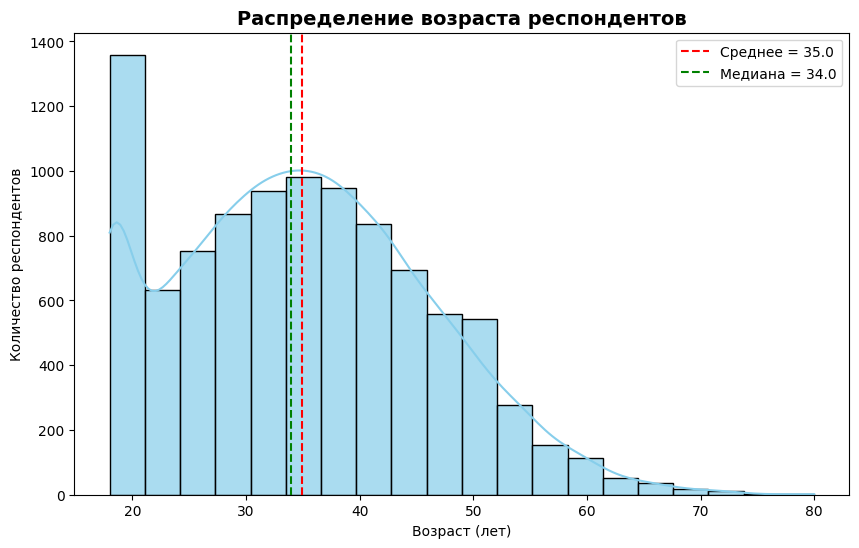

In [34]:
# Гистограмма для Age
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Распределение возраста респондентов', fontsize=14, fontweight='bold')
plt.xlabel('Возраст (лет)')
plt.ylabel('Количество респондентов')
plt.axvline(df['age'].mean(), color='red', linestyle='--', label=f'Среднее = {df["age"].mean():.1f}')
plt.axvline(df['age'].median(), color='green', linestyle='--', label=f'Медиана = {df["age"].median():.1f}')
plt.legend()
plt.show()

**Вывод:**



Распределение возраста имеет пик в районе **20 лет**, после чего плавно снижается.
Основная масса респондентов сосредоточена в диапазоне **20–50 лет**, средний возраст составляет **~35 лет**, медиана — **~34 года**.
Минимальный возраст — **18 лет**, максимальный — **80 лет**.

Выявленный пик в районе 20 лет указывает на то, что в выборке присутствует значительное количество молодых респондентов.
Это стоит учитывать при интерпретации результатов, поскольку молодёжь может иметь иные паттерны потребления кофе и показателей здоровья по сравнению со старшими возрастными группами.

### Coffee_Intake

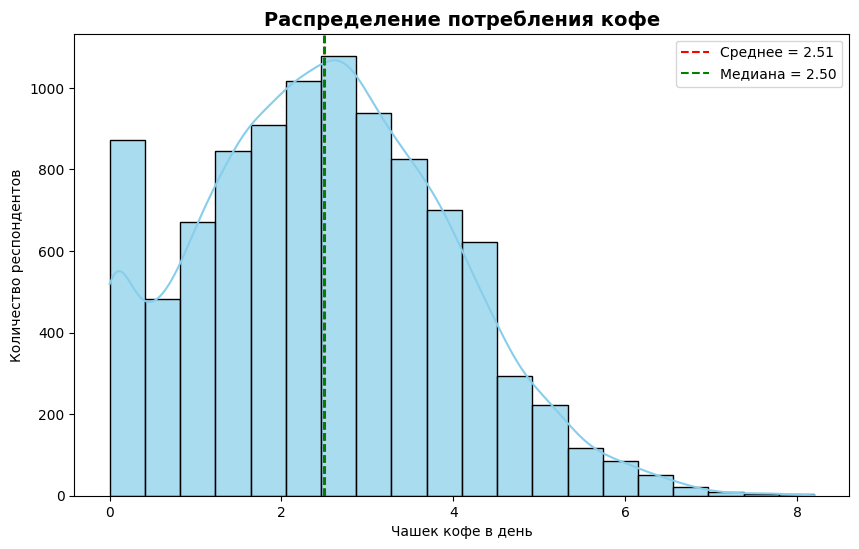

In [35]:
plt.figure(figsize=(10, 6))
sns.histplot(df['coffee_intake'], bins=20, kde=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Распределение потребления кофе', fontsize=14, fontweight='bold')
plt.xlabel('Чашек кофе в день')
plt.ylabel('Количество респондентов')
plt.axvline(df['coffee_intake'].mean(), color='red', linestyle='--', label=f'Среднее = {df["coffee_intake"].mean():.2f}')
plt.axvline(df['coffee_intake'].median(), color='green', linestyle='--', label=f'Медиана = {df["coffee_intake"].median():.2f}')
plt.legend()
plt.show()

In [36]:
round(df['coffee_intake']).value_counts()

,count
coffee_intake,
2.0,2639
3.0,2182
4.0,1723
1.0,1418
0.0,1003
5.0,558
6.0,213
7.0,30
8.0,8


**Вывод:**

Распределение потребления кофе показывает, что наибольшее количество респондентов употребляет **2 чашки кофе в день (2702 человека)**, за ними следуют употребляющие **3 чашки (2234 человека)**. Таким образом, основная масса респондентов **(почти 50% выборки) потребляет 2–3 чашки кофе в день**.

Количество людей, употребляющих **1 чашку или не пьющих кофе вовсе, составляет 1450 и 1028 человек** соответственно.

При этом наблюдается длинный правый хвост распределения:

**576 человек пьют 5 чашек, 220 — 6 чашек, и есть респонденты с потреблением до 8 чашек в день (8 человек)**

### Sleep_Hours

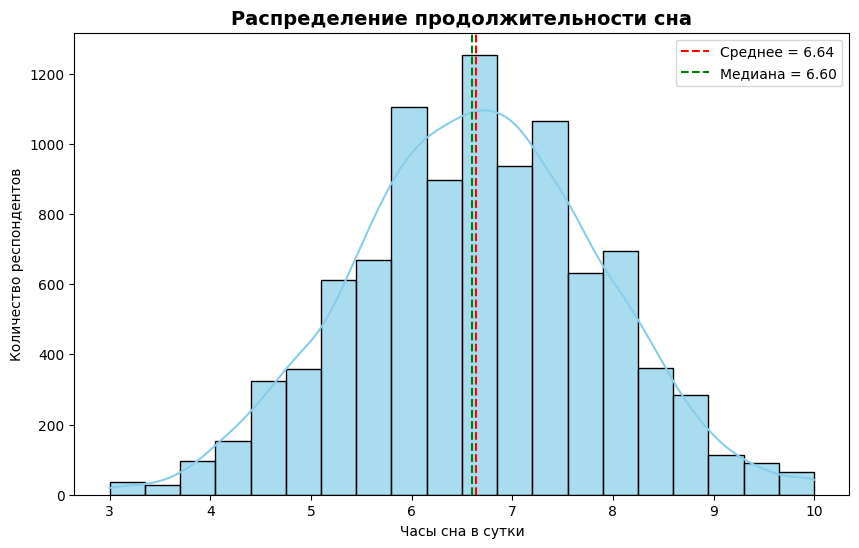

In [37]:
plt.figure(figsize=(10, 6))
sns.histplot(df['sleep_hours'], bins=20, kde=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Распределение продолжительности сна', fontsize=14, fontweight='bold')
plt.xlabel('Часы сна в сутки')
plt.ylabel('Количество респондентов')
plt.axvline(df['sleep_hours'].mean(), color='red', linestyle='--', label=f'Среднее = {df["sleep_hours"].mean():.2f}')
plt.axvline(df['sleep_hours'].median(), color='green', linestyle='--', label=f'Медиана = {df["sleep_hours"].median():.2f}')
plt.legend()
plt.show()

In [38]:
df['sleep_hours'].describe()

,sleep_hours
count,9774.000000
mean,6.637211
std,1.222802
min,3.000000
25%,5.800000
50%,6.600000
75%,7.500000
max,10.000000


**Вывод:**

Большинство респондентов спят **6–7** часов в сутки. Средняя продолжительность сна составляет **~6.6** часа, медиана — **~6.6** часа.
Минимальное значение — **3** часа, максимальное — **10** часов.

**Около 25% респондентов спят менее 5.8 часов**, что указывает на значительную долю людей с недостаточной продолжительностью сна.

### Heart_Rate

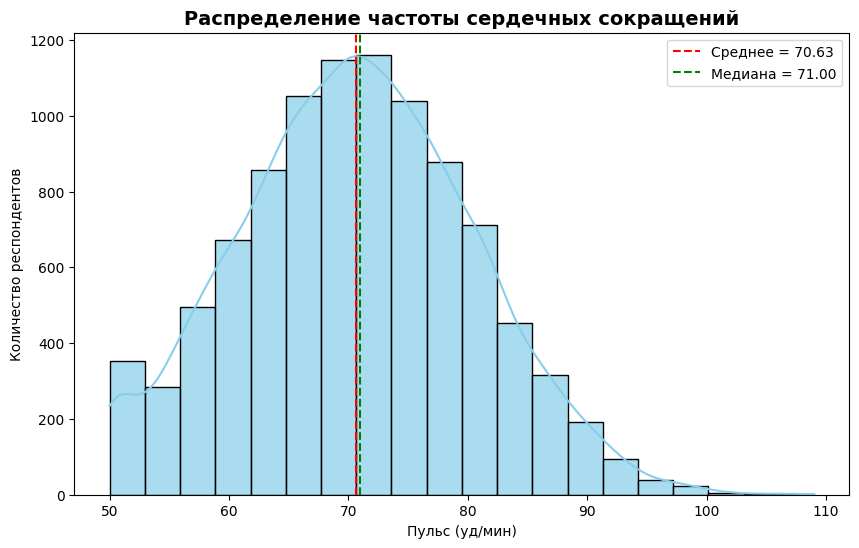

In [39]:
plt.figure(figsize=(10, 6))
sns.histplot(df['heart_rate'], bins=20, kde=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Распределение частоты сердечных сокращений', fontsize=14, fontweight='bold')
plt.xlabel('Пульс (уд/мин)')
plt.ylabel('Количество респондентов')
plt.axvline(df['heart_rate'].mean(), color='red', linestyle='--', label=f'Среднее = {df["heart_rate"].mean():.2f}')
plt.axvline(df['heart_rate'].median(), color='green', linestyle='--', label=f'Медиана = {df["heart_rate"].median():.2f}')
plt.legend()
plt.show()

In [40]:
df['heart_rate'].describe()

,heart_rate
count,9774.000000
mean,70.629016
std,9.817483
min,50.000000
25%,64.000000
50%,71.000000
75%,77.000000
max,109.000000


**Вывод:**

Распределение пульса близко к нормальному. Среднее значение составляет **~70.6** уд/мин, медиана — **71** уд/мин, что соответствует физиологической норме **(60–80 уд/мин)**.

**Основная масса респондентов имеет пульс в диапазоне 67–75 уд/мин.**

Наблюдается небольшой правый хвост: **64 человека имеют пульс выше 90 уд/мин (максимум — 109 уд/мин)**.

### BMI

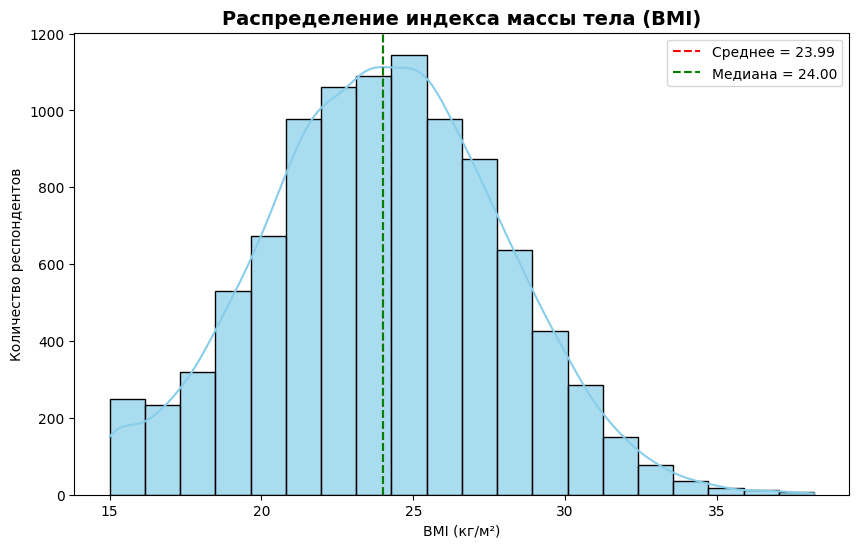

In [41]:
plt.figure(figsize=(10, 6))
sns.histplot(df['bmi'], bins=20, kde=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Распределение индекса массы тела (BMI)', fontsize=14, fontweight='bold')
plt.xlabel('BMI (кг/м²)')
plt.ylabel('Количество респондентов')
plt.axvline(df['bmi'].mean(), color='red', linestyle='--', label=f'Среднее = {df["bmi"].mean():.2f}')
plt.axvline(df['bmi'].median(), color='green', linestyle='--', label=f'Медиана = {df["bmi"].median():.2f}')
plt.legend()
plt.show()

In [42]:
df['bmi'].describe()

,bmi
count,9774.000000
mean,23.989196
std,3.908612
min,15.000000
25%,21.300000
50%,24.000000
75%,26.600000
max,38.200000


**Вывод:**

Распределение индекса массы тела близко к нормальному. Среднее значение BMI составляет **~24.0**, медиана — **24.0**, что соответствует верхней границе нормы (18.5–24.9).

**Основная масса респондентов сосредоточена в диапазоне 21.3–26.6 (от 25-го до 75-го процентиля)**. Минимальное значение — **15.0** (недостаточный вес), максимальное — **38.2** (ожирение).

Практически вся выборка (**99.7%** по правилу трёх сигм (стандатрое отклонение)) находится в пределах от **12.3 до 35.7**, что указывает на отсутствие экстремальных выбросов, способных исказить результаты анализа.

## Визуализация категориальных переменных

### Gender

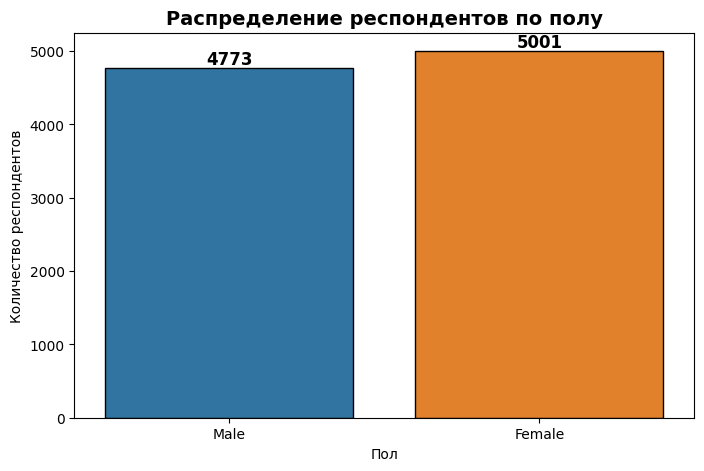

In [43]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='gender',hue='gender', edgecolor='black')
plt.title('Распределение респондентов по полу', fontsize=14, fontweight='bold')
plt.xlabel('Пол')
plt.ylabel('Количество респондентов')

# Подписи значений на столбцах
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 50,
            int(p.get_height()), ha='center', fontsize=12, fontweight='bold')

plt.show()

**Вывод:**

Распределение респондентов по полу сбалансировано: **женщины составляют 51.2%** выборки (5001 человек), **мужчины — 48.8%** (4773 человека).

Небольшой перевес в сторону женщин не является критическим и позволяет проводить корректные сравнения между группами без существенного смещения результатов.

### Stress_Level

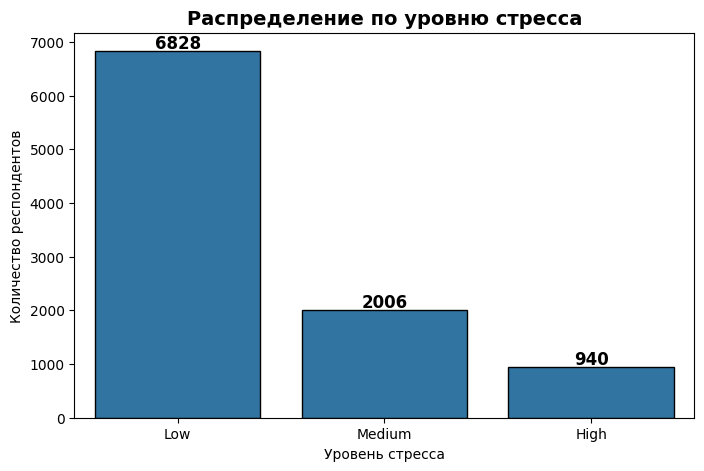

In [44]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='stress_level', edgecolor='black', order=['Low', 'Medium', 'High'])
plt.title('Распределение по уровню стресса', fontsize=14, fontweight='bold')
plt.xlabel('Уровень стресса')
plt.ylabel('Количество респондентов')

for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 50,
            int(p.get_height()), ha='center', fontsize=12, fontweight='bold')

plt.show()

**Вывод:**

Распределение по уровню стресса имеет выраженный перекос в сторону низких значений: **68.3%** респондентов оценивают свой стресс как низкий, **20.1%** — как средний, и лишь **9.4%** — как высокий.

Такая асимметрия характерна для популяционных данных и может указывать на то, что выборка состоит преимущественно из людей с низким уровнем стресса. Это стоит учитывать при проверке гипотезы о связи стресса с потреблением кофе — небольшой размер группы High может снизить чувствительность анализа.

### Coffee_Drinker_Type

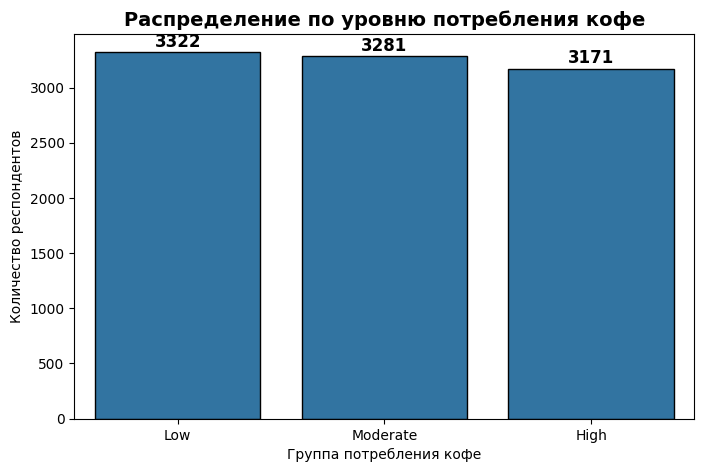

In [45]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='coffee_drinker_type', edgecolor='black', order=['Low', 'Moderate', 'High'])
plt.title('Распределение по уровню потребления кофе', fontsize=14, fontweight='bold')
plt.xlabel('Группа потребления кофе')
plt.ylabel('Количество респондентов')

for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 50,
            int(p.get_height()), ha='center', fontsize=12, fontweight='bold')

plt.show()

**Вывод:**

Распределение по группам потребления кофе сбалансировано. Группа Low составляет **33.2%** выборки (3322 человека), Moderate — **32.8%** (3281 человек), High — **31.7%** (3171 человек). Разница между группами не превышает 1.5%, что позволяет проводить корректные сравнения.

## Корреляции

### Матрица корреляций

In [46]:
# Выбираем числовые колонки
numeric_cols = ['age', 'coffee_intake', 'sleep_hours', 'heart_rate', 'bmi']

# Строим матрицу корреляций
corr_matrix = df[numeric_cols].corr()
corr_matrix

,age,coffee_intake,sleep_hours,heart_rate,bmi
age,1.000000,-0.012599,0.002862,0.001028,0.008179
coffee_intake,-0.012599,1.000000,-0.188964,0.058498,-0.007837
sleep_hours,0.002862,-0.188964,1.000000,-0.038143,0.007325
heart_rate,0.001028,0.058498,-0.038143,1.000000,-0.009823
bmi,0.008179,-0.007837,0.007325,-0.009823,1.000000


### Тепловая карта для всех числовых переменных

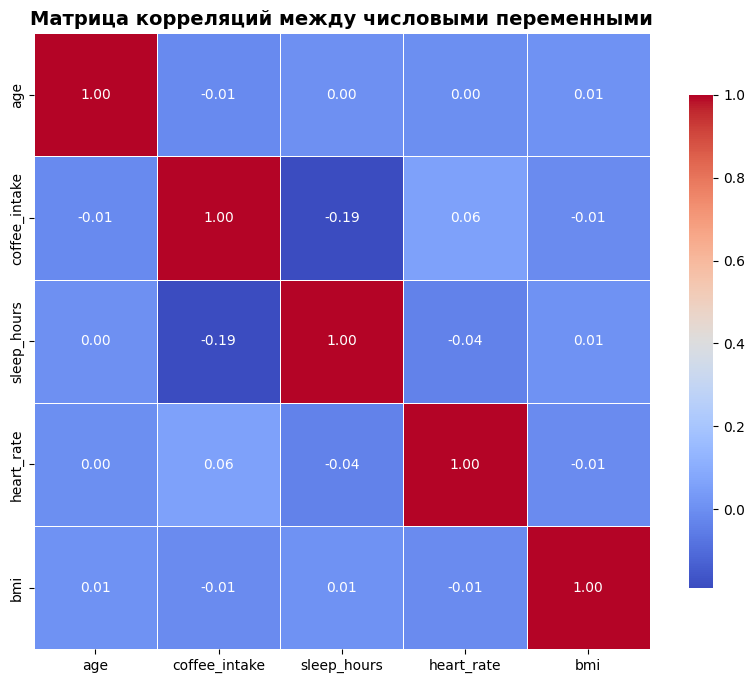

In [47]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})

plt.title('Матрица корреляций между числовыми переменными', fontsize=14, fontweight='bold')
plt.show()

**Вывод:**

Матрица корреляций показывает, что сильных взаимосвязей между переменными не обнаружено. Наибольший интерес представляет слабая отрицательная корреляция между потреблением кофе и продолжительностью сна **(r = -0.19)**. Связь кофе с пульсом **(r = 0.06)**, возрастом **(r = -0.01)** и ИМТ **(r = -0.01)** практически отсутствует. Остальные переменные также независимы друг от друга. Сильных корреляций нет.

# Проверка гипотез

## ГИПОТЕЗА №1: Влияние кофе на продолжительность сна

H₀: Потребление кофе не влияет на продолжительность сна

H₁: Потребление кофе сокращает продолжительность сна

**Уровень значимости alpha = 0.05**

### Визуализация Boxplot

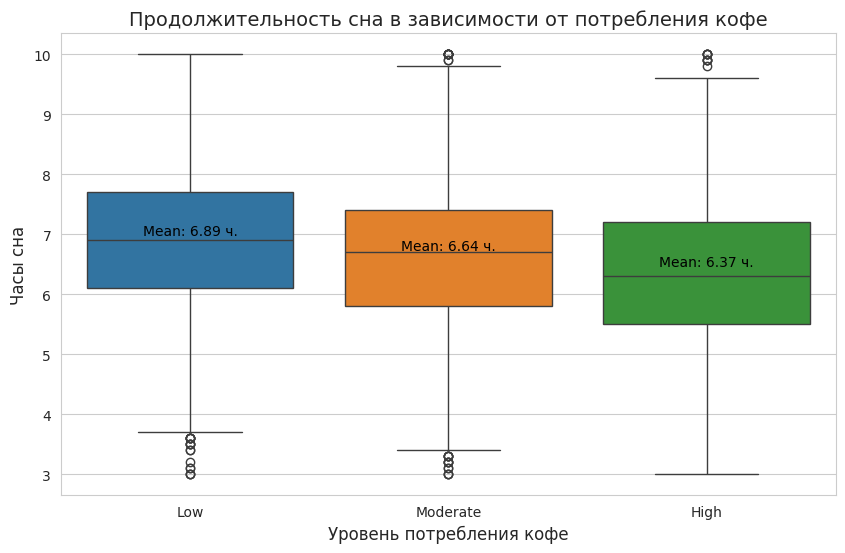

In [70]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='coffee_drinker_type', y='sleep_hours', hue='coffee_drinker_type',
            data=df, order=['Low', 'Moderate', 'High'],
            legend=False)  # legend=False убирает дублирующую легенду

plt.title('Продолжительность сна в зависимости от потребления кофе', fontsize=14)
plt.xlabel('Уровень потребления кофе', fontsize=12)
plt.ylabel('Часы сна', fontsize=12)

# Добавляем средние значения
means = df.groupby('coffee_drinker_type', observed=False)['sleep_hours'].mean()
for i, level in enumerate(['Low', 'Moderate', 'High']):
    plt.text(i, means[level] + 0.1, f'Mean: {means[level]:.2f} ч.',
             ha='center', fontsize=10, color='black')

plt.show()

### Корреляция Пирсона (по всей выборке)

In [54]:
alpha = 0.05

corr, p_value = st.pearsonr(df['coffee_intake'], df['sleep_hours'])

print(f'Коэффициент корреляции r = {corr:.3f}')
print(f'p-value = {p_value:.6f}')
print()

if p_value < alpha:
    print('Отвергаем нулевую гипотезу')
    print('→ Статистически значимая связь между кофе и сном есть')
else:
    print('Не получилось отвергнуть нулевую гипотезу')
    print('→ Статистически значимой связи между кофе и сном нет')

Коэффициент корреляции r = -0.189
p-value = 0.000000

Отвергаем нулевую гипотезу
→ Статистически значимая связь между кофе и сном есть


### ANOVA (показывает различия между группами, но не между какими именно)

In [53]:
# Формируем три группы
group_low = df.query('coffee_drinker_type == "Low"')['sleep_hours']
group_moderate = df.query('coffee_drinker_type == "Moderate"')['sleep_hours']
group_high = df.query('coffee_drinker_type == "High"')['sleep_hours']

# ANOVA
anova_result = st.f_oneway(group_low, group_moderate, group_high)

print(f'F-статистика = {anova_result.statistic:.3f}')
print(f'p-value = {anova_result.pvalue:.6f}')
print()

if anova_result.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
    print('→ Между группами есть статистически значимые различия')
else:
    print('Не получилось отвергнуть нулевую гипотезу')
    print('→ Статистически значимых различий между группами нет')

F-статистика = 150.640
p-value = 0.000000

Отвергаем нулевую гипотезу
→ Между группами есть статистически значимые различия


### t-test

#### Low vs Moderate

In [55]:
alpha = 0.05

sample_low = df.query('coffee_drinker_type == "Low"')['sleep_hours']
sample_mod = df.query('coffee_drinker_type == "Moderate"')['sleep_hours']

results = st.ttest_ind(sample_low, sample_mod, equal_var=False)

print(f'Средний сон Low: {sample_low.mean():.2f} ч.')
print(f'Средний сон Moderate: {sample_mod.mean():.2f} ч.')
print(f'p-value = {results.pvalue:.6f}')
print()

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
    print('→ Low и Moderate различаются')
else:
    print('Не получилось отвергнуть нулевую гипотезу')
    print('→ Low и Moderate не различаются')

Средний сон Low: 6.89 ч.
Средний сон Moderate: 6.64 ч.
p-value = 0.000000

Отвергаем нулевую гипотезу
→ Low и Moderate различаются


#### Low vs High

In [57]:
sample_high = df.query('coffee_drinker_type == "High"')['sleep_hours']

results = st.ttest_ind(sample_low, sample_high, equal_var=False)

print(f'Средний сон Low: {sample_low.mean():.2f} ч.')
print(f'Средний сон High: {sample_high.mean():.2f} ч.')
print(f'p-value = {results.pvalue:.6f}')
print()

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
    print('→ Low и High различаются')
else:
    print('Не получилось отвергнуть нулевую гипотезу')
    print('→ Low и High не различаются')

Средний сон Low: 6.89 ч.
Средний сон High: 6.37 ч.
p-value = 0.000000

Отвергаем нулевую гипотезу
→ Low и High различаются


#### Moderate vs High

In [58]:
results = st.ttest_ind(sample_mod, sample_high, equal_var=False)

print(f'Средний сон Moderate: {sample_mod.mean():.2f} ч.')
print(f'Средний сон High: {sample_high.mean():.2f} ч.')
print(f'p-value = {results.pvalue:.6f}')
print()

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
    print('→ Moderate и High различаются')
else:
    print('Не получилось отвергнуть нулевую гипотезу')
    print('→ Moderate и High не различаются')

Средний сон Moderate: 6.64 ч.
Средний сон High: 6.37 ч.
p-value = 0.000000

Отвергаем нулевую гипотезу
→ Moderate и High различаются


### Вывод

Корреляционный анализ выявил отрицательную связь между количеством выпитого кофе и часами сна (r = -0.189, p < 0.001).

Однофакторный дисперсионный анализ (ANOVA) показал статистически значимые различия между группами потребителей кофе (F = 150.64, p < 0.001).

Попарные сравнения (t-критерий Уэлча) подтвердили значимые различия между всеми группами (p < 0.001):

Low (M = 6.89, SD = ...) vs Moderate (M = 6.64, SD = ...)

Low (M = 6.89, SD = ...) vs High (M = 6.37, SD = ...)

Moderate (M = 6.64, SD = ...) vs High (M = 6.37, SD = ...)

Таким образом, потребление кофе ассоциировано с уменьшением продолжительности сна: чем выше уровень потребления кофе, тем меньше часов сна.

## Гипотеза №2: Влияние кофе на частоту сердечных сокращений

H₀: Кофе не влияет на частоту пульса

H₁: Кофе положительно коррелирует с пульсом

**alpha = 0.05**

### Визуалзация Boxplot

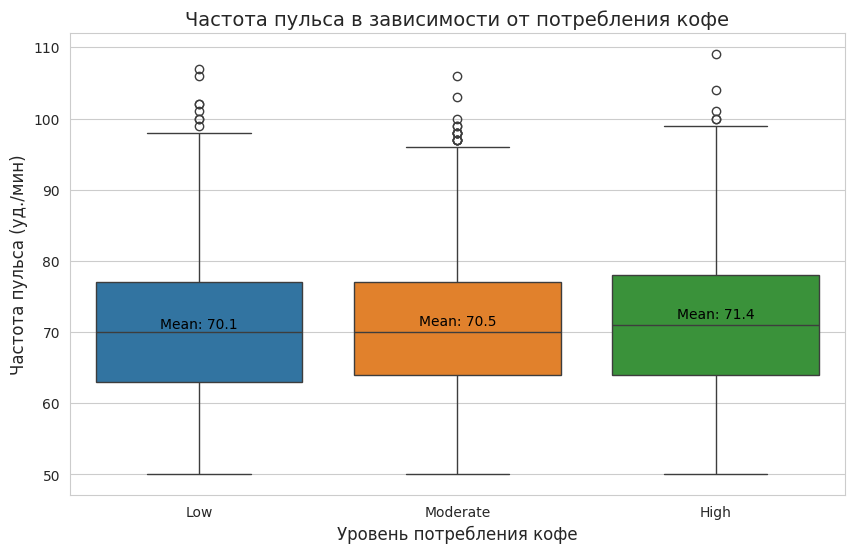

In [69]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='coffee_drinker_type', y='heart_rate',
            hue='coffee_drinker_type',
            data=df,
            order=['Low', 'Moderate', 'High'],
            legend=False)

plt.title('Частота пульса в зависимости от потребления кофе', fontsize=14)
plt.xlabel('Уровень потребления кофе', fontsize=12)
plt.ylabel('Частота пульса (уд./мин)', fontsize=12)

# Средние значения
means = df.groupby('coffee_drinker_type', observed=False)['heart_rate'].mean()
for i, level in enumerate(['Low', 'Moderate', 'High']):
    plt.text(i, means[level] + 0.5, f'Mean: {means[level]:.1f}',
             ha='center', fontsize=10, color='black')

plt.show()

### Коррелляция Пирсона (по всей выборке)

In [72]:
alpha = 0.05

# Корреляция между количеством кофе и пульсом
corr, p_value = st.pearsonr(df['coffee_intake'], df['heart_rate'])

print(f'Коэффициент корреляции r = {corr:.3f}')
print(f'p-value = {p_value:.6f}')
print()

if p_value < alpha:
    print('Отвергаем нулевую гипотезу')
    print('→ Статистически значимая связь между кофе и пульсом есть')
else:
    print('Не получилось отвергнуть нулевую гипотезу')
    print('→ Статистически значимой связи между кофе и пульсом нет')

Коэффициент корреляции r = 0.058
p-value = 0.000000

Отвергаем нулевую гипотезу
→ Статистически значимая связь между кофе и пульсом есть


### ANOVA (показывает различия между группами, но не между какими именно)

In [73]:
# Формируем три группы
group_low = df.query('coffee_drinker_type == "Low"')['heart_rate']
group_moderate = df.query('coffee_drinker_type == "Moderate"')['heart_rate']
group_high = df.query('coffee_drinker_type == "High"')['heart_rate']

# ANOVA
anova_result = st.f_oneway(group_low, group_moderate, group_high)

print(f'F-статистика = {anova_result.statistic:.3f}')
print(f'p-value = {anova_result.pvalue:.6f}')
print()

if anova_result.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
    print('→ Между группами есть статистически значимые различия по пульсу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')
    print('→ Статистически значимых различий между группами по пульсу нет')

F-статистика = 15.165
p-value = 0.000000

Отвергаем нулевую гипотезу
→ Между группами есть статистически значимые различия по пульсу


### t-test

#### Low vs Moderate

In [74]:
sample_low = df.query('coffee_drinker_type == "Low"')['heart_rate']
sample_mod = df.query('coffee_drinker_type == "Moderate"')['heart_rate']

results = st.ttest_ind(sample_low, sample_mod, equal_var=False)

print(f'Средний пульс Low: {sample_low.mean():.1f} уд./мин')
print(f'Средний пульс Moderate: {sample_mod.mean():.1f} уд./мин')
print(f'p-value = {results.pvalue:.6f}')
print()

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
    print('→ Low и Moderate различаются по пульсу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')
    print('→ Low и Moderate не различаются по пульсу')

Средний пульс Low: 70.1 уд./мин
Средний пульс Moderate: 70.5 уд./мин
p-value = 0.088359

Не получилось отвергнуть нулевую гипотезу
→ Low и Moderate не различаются по пульсу


 #### Low vs High

In [75]:
sample_high = df.query('coffee_drinker_type == "High"')['heart_rate']

results = st.ttest_ind(sample_low, sample_high, equal_var=False)

print(f'Средний пульс Low: {sample_low.mean():.1f} уд./мин')
print(f'Средний пульс High: {sample_high.mean():.1f} уд./мин')
print(f'p-value = {results.pvalue:.6f}')
print()

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
    print('→ Low и High различаются по пульсу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')
    print('→ Low и High не различаются по пульсу')

Средний пульс Low: 70.1 уд./мин
Средний пульс High: 71.4 уд./мин
p-value = 0.000000

Отвергаем нулевую гипотезу
→ Low и High различаются по пульсу


#### Moderate vs High

In [77]:
results = st.ttest_ind(sample_mod, sample_high, equal_var=False)

print(f'Средний пульс Moderate: {sample_mod.mean():.1f} уд./мин')
print(f'Средний пульс High: {sample_high.mean():.1f} уд./мин')
print(f'p-value = {results.pvalue:.6f}')
print()

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
    print('→ Moderate и High различаются по пульсу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')
    print('→ Moderate и High не различаются по пульсу')

Средний пульс Moderate: 70.5 уд./мин
Средний пульс High: 71.4 уд./мин
p-value = 0.000222

Отвергаем нулевую гипотезу
→ Moderate и High различаются по пульсу


### Вывод

Корреляционный анализ выявил статистически значимую, но очень слабую положительную связь между количеством выпитого кофе и частотой пульса (r = 0.058, p < 0.001).

Однофакторный дисперсионный анализ (ANOVA) показал статистически значимые различия между группами потребителей кофе по частоте пульса (F = 15.165, p < 0.001).

Попарные сравнения выявили:

Low (M = 70.1) vs Moderate (M = 70.5) — различия не значимы (p = 0.088)

Low (M = 70.1) vs High (M = 71.4) — различия значимы (p < 0.001)

Moderate (M = 70.5) vs High (M = 71.4) — различия значимы (p = 0.000222)

Таким образом, потребление кофе ассоциировано с повышением частоты пульса, однако эффект выражен преимущественно при высоком уровне потребления кофе. Различия между группами Low и Moderate статистически не значимы.

## ГИПОТЕЗА: Связь кофе с уровнем стресса

H₀: Уровень стресса не зависит от потребления кофе

H₁: Уровень стресса связан с потреблением кофе

**alpha = 0.05**

### Визуализация (столбчатая диаграмма)

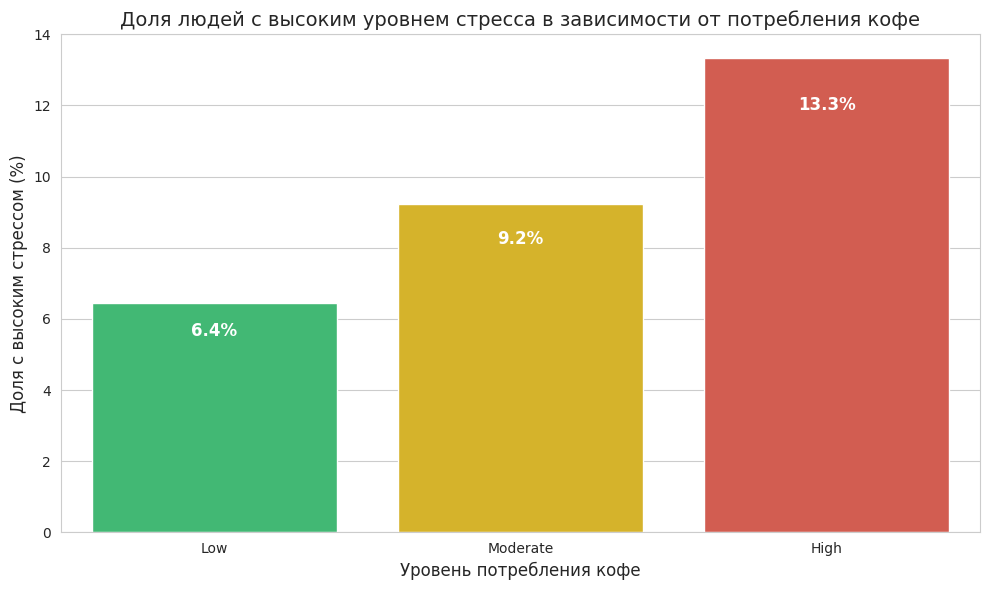

In [81]:
# Считаем долю людей с высоким стрессом в каждой группе
stress_by_group = df.groupby('coffee_drinker_type', observed=False)['stress_high'].mean().reset_index()
stress_by_group['stress_high'] = stress_by_group['stress_high'] * 100

# Столбчатая диаграмма
plt.figure(figsize=(10, 6))
sns.barplot(x='coffee_drinker_type', y='stress_high',
            hue='coffee_drinker_type',
            data=stress_by_group,
            order=['Low', 'Moderate', 'High'],
            palette=['#2ecc71', '#f1c40f', '#e74c3c'],
            legend=False)

plt.title('Доля людей с высоким уровнем стресса в зависимости от потребления кофе', fontsize=14)
plt.xlabel('Уровень потребления кофе', fontsize=12)
plt.ylabel('Доля с высоким стрессом (%)', fontsize=12)

# Добавляем значения ВНУТРИ столбцов (у верхнего края)
for i, row in enumerate(stress_by_group.iterrows()):
    value = row[1]['stress_high']
    # Размещаем текст чуть ниже верхнего края столбца
    plt.text(i, value - (value * 0.08), f'{value:.1f}%',
             ha='center', va='top', fontsize=12, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

### Коррелляция Пирсона (по всей выборке)

In [87]:
df.head()

,id,age,gender,country,coffee_intake,caffeine_mg,sleep_hours,sleep_quality,bmi,heart_rate,stress_level,physical_activity_hours,occupation,smoking,alcohol_consumption,coffee_drinker_type,age_group,stress_high,bmi_category
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,Other,0,0,High,31-45,0,Норма
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,Service,0,0,Low,31-45,0,Норма
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Office,0,0,High,31-45,0,Норма
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Other,0,0,Moderate,46-60,0,Норма
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Student,0,1,Moderate,31-45,0,Норма


In [88]:
alpha = 0.05

# Для рассчета коррелляции надо преобразовать категории из столбца "stress_level"
# в числовой формат


# Преобразуем stress_level в числа
stress_map = {
    'Low': 1,
    'Medium': 2,
    'High': 3
}
df['stress_level_numeric'] = df['stress_level'].map(stress_map)

alpha = 0.05

# Корреляция между количеством кофе и уровнем стресса (числовая шкала)
corr, p_value = st.pearsonr(df['coffee_intake'], df['stress_level_numeric'])

print(f'Коэффициент корреляции r = {corr:.3f}')
print(f'p-value = {p_value:.6f}')
print()

if p_value < alpha:
    print('Отвергаем нулевую гипотезу')
    print('→ Статистически значимая связь между кофе и стрессом есть')
else:
    print('Не получилось отвергнуть нулевую гипотезу')
    print('→ Статистически значимой связи между кофе и стрессом нет')

Коэффициент корреляции r = 0.150
p-value = 0.000000

Отвергаем нулевую гипотезу
→ Статистически значимая связь между кофе и стрессом есть


### ANOVA

In [89]:
# Формируем три группы по уровню стресса (числовая шкала)
group_low = df.query('coffee_drinker_type == "Low"')['stress_level_numeric']
group_moderate = df.query('coffee_drinker_type == "Moderate"')['stress_level_numeric']
group_high = df.query('coffee_drinker_type == "High"')['stress_level_numeric']

# ANOVA
anova_result = st.f_oneway(group_low, group_moderate, group_high)

print(f'F-статистика = {anova_result.statistic:.3f}')
print(f'p-value = {anova_result.pvalue:.6f}')
print()

if anova_result.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
    print('→ Между группами есть статистически значимые различия по уровню стресса')
else:
    print('Не получилось отвергнуть нулевую гипотезу')
    print('→ Статистически значимых различий между группами по уровню стресса нет')

F-статистика = 95.298
p-value = 0.000000

Отвергаем нулевую гипотезу
→ Между группами есть статистически значимые различия по уровню стресса


### t-test

#### Low vs Moderate

In [90]:
sample_low = df.query('coffee_drinker_type == "Low"')['stress_level_numeric']
sample_mod = df.query('coffee_drinker_type == "Moderate"')['stress_level_numeric']

results = st.ttest_ind(sample_low, sample_mod, equal_var=False)

print(f'Средний стресс Low: {sample_low.mean():.2f}')
print(f'Средний стресс Moderate: {sample_mod.mean():.2f}')
print(f'p-value = {results.pvalue:.6f}')
print()

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
    print('→ Low и Moderate различаются по уровню стресса')
else:
    print('Не получилось отвергнуть нулевую гипотезу')
    print('→ Low и Moderate не различаются по уровню стресса')

Средний стресс Low: 1.30
Средний стресс Moderate: 1.38
p-value = 0.000000

Отвергаем нулевую гипотезу
→ Low и Moderate различаются по уровню стресса


#### Low vs High

In [91]:
sample_high = df.query('coffee_drinker_type == "High"')['stress_level_numeric']

results = st.ttest_ind(sample_low, sample_high, equal_var=False)

print(f'Средний стресс Low: {sample_low.mean():.2f}')
print(f'Средний стресс High: {sample_high.mean():.2f}')
print(f'p-value = {results.pvalue:.6f}')
print()

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
    print('→ Low и High различаются по уровню стресса')
else:
    print('Не получилось отвергнуть нулевую гипотезу')
    print('→ Low и High не различаются по уровню стресса')

Средний стресс Low: 1.30
Средний стресс High: 1.52
p-value = 0.000000

Отвергаем нулевую гипотезу
→ Low и High различаются по уровню стресса


#### Moderate vs High

In [92]:
results = st.ttest_ind(sample_mod, sample_high, equal_var=False)

print(f'Средний стресс Moderate: {sample_mod.mean():.2f}')
print(f'Средний стресс High: {sample_high.mean():.2f}')
print(f'p-value = {results.pvalue:.6f}')
print()

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
    print('→ Moderate и High различаются по уровню стресса')
else:
    print('Не получилось отвергнуть нулевую гипотезу')
    print('→ Moderate и High не различаются по уровню стресса')

Средний стресс Moderate: 1.38
Средний стресс High: 1.52
p-value = 0.000000

Отвергаем нулевую гипотезу
→ Moderate и High различаются по уровню стресса


### Вывод

Корреляционный анализ выявил статистически значимую положительную связь между количеством выпитого кофе и уровнем стресса (r = 0.150, p < 0.001).

Однофакторный дисперсионный анализ (ANOVA) показал статистически значимые различия между группами потребителей кофе по уровню стресса (F = 95.298, p < 0.001).

Попарные сравнения (t-критерий Уэлча) подтвердили значимые различия между всеми группами (p < 0.001):

Low (M = 1.30) vs Moderate (M = 1.38)

Low (M = 1.30) vs High (M = 1.52)

Moderate (M = 1.38) vs High (M = 1.52)

Таким образом, потребление кофе ассоциировано с повышением уровня стресса: чем выше уровень потребления кофе, тем выше уровень стресса.

## ГИПОТЕЗА: Связь кофе с ИМТ(индекс массы тела)

H₀: Кофе не влияет на ИМТ (null-гипотеза)

H₁: Кофе влияет на ИМТ

**alpha = 0.05**

### Визуализация Boxplot

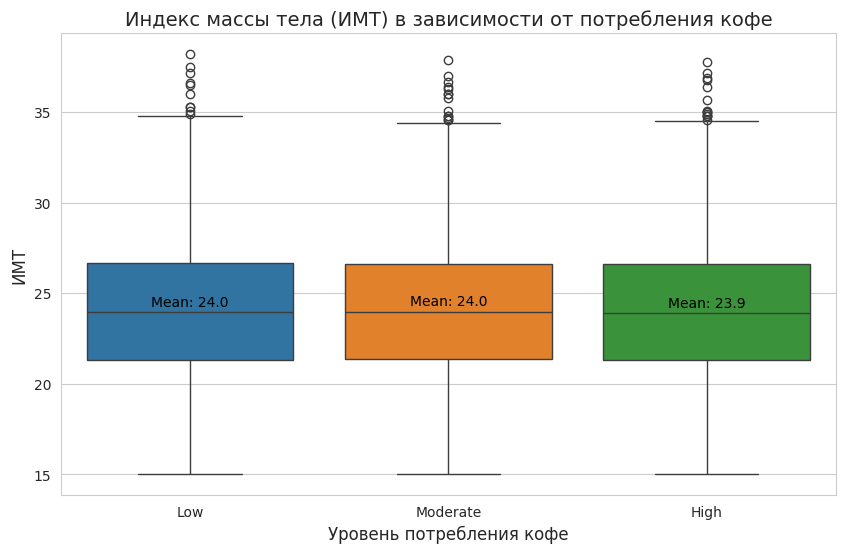

In [93]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='coffee_drinker_type', y='bmi',
            hue='coffee_drinker_type',
            data=df,
            order=['Low', 'Moderate', 'High'],
            legend=False)

plt.title('Индекс массы тела (ИМТ) в зависимости от потребления кофе', fontsize=14)
plt.xlabel('Уровень потребления кофе', fontsize=12)
plt.ylabel('ИМТ', fontsize=12)

# Добавляем средние значения
means = df.groupby('coffee_drinker_type', observed=False)['bmi'].mean()
for i, level in enumerate(['Low', 'Moderate', 'High']):
    plt.text(i, means[level] + 0.3, f'Mean: {means[level]:.1f}',
             ha='center', fontsize=10, color='black')

plt.show()

### Коррелляция Пирсона (по всем выборке)

In [95]:
alpha = 0.05

corr, p_value = st.pearsonr(df['coffee_intake'], df['bmi'])

print(f'Коэффициент корреляции r = {corr:.3f}')
print(f'p-value = {p_value:.6f}')
print()

if p_value < alpha:
    print('Отвергаем нулевую гипотезу')
    print('→ Статистически значимая связь между кофе и ИМТ есть')
else:
    print('Не получилось отвергнуть нулевую гипотезу')
    print('→ Статистически значимой связи между кофе и ИМТ нет')

Коэффициент корреляции r = -0.008
p-value = 0.438504

Не получилось отвергнуть нулевую гипотезу
→ Статистически значимой связи между кофе и ИМТ нет


### ANOVA

In [96]:
# Формируем три группы по ИМТ
group_low = df.query('coffee_drinker_type == "Low"')['bmi']
group_moderate = df.query('coffee_drinker_type == "Moderate"')['bmi']
group_high = df.query('coffee_drinker_type == "High"')['bmi']

# ANOVA
anova_result = st.f_oneway(group_low, group_moderate, group_high)

print(f'F-статистика = {anova_result.statistic:.3f}')
print(f'p-value = {anova_result.pvalue:.6f}')
print()

if anova_result.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
    print('→ Между группами есть статистически значимые различия по ИМТ')
else:
    print('Не получилось отвергнуть нулевую гипотезу')
    print('→ Статистически значимых различий между группами по ИМТ нет')

F-статистика = 0.490
p-value = 0.612886

Не получилось отвергнуть нулевую гипотезу
→ Статистически значимых различий между группами по ИМТ нет


### t-test

#### Low vs Moderate

In [97]:
sample_low = df.query('coffee_drinker_type == "Low"')['bmi']
sample_mod = df.query('coffee_drinker_type == "Moderate"')['bmi']

results = st.ttest_ind(sample_low, sample_mod, equal_var=False)

print(f'Средний ИМТ Low: {sample_low.mean():.2f}')
print(f'Средний ИМТ Moderate: {sample_mod.mean():.2f}')
print(f'p-value = {results.pvalue:.6f}')
print()

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
    print('→ Low и Moderate различаются по ИМТ')
else:
    print('Не получилось отвергнуть нулевую гипотезу')
    print('→ Low и Moderate не различаются по ИМТ')

Средний ИМТ Low: 24.00
Средний ИМТ Moderate: 24.03
p-value = 0.792941

Не получилось отвергнуть нулевую гипотезу
→ Low и Moderate не различаются по ИМТ


#### Low vs High

In [98]:
sample_high = df.query('coffee_drinker_type == "High"')['bmi']

results = st.ttest_ind(sample_low, sample_high, equal_var=False)

print(f'Средний ИМТ Low: {sample_low.mean():.2f}')
print(f'Средний ИМТ High: {sample_high.mean():.2f}')
print(f'p-value = {results.pvalue:.6f}')
print()

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
    print('→ Low и High различаются по ИМТ')
else:
    print('Не получилось отвергнуть нулевую гипотезу')
    print('→ Low и High не различаются по ИМТ')

Средний ИМТ Low: 24.00
Средний ИМТ High: 23.93
p-value = 0.484214

Не получилось отвергнуть нулевую гипотезу
→ Low и High не различаются по ИМТ


#### Moderate vs High

In [99]:
results = st.ttest_ind(sample_mod, sample_high, equal_var=False)

print(f'Средний ИМТ Moderate: {sample_mod.mean():.2f}')
print(f'Средний ИМТ High: {sample_high.mean():.2f}')
print(f'p-value = {results.pvalue:.6f}')
print()

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
    print('→ Moderate и High различаются по ИМТ')
else:
    print('Не получилось отвергнуть нулевую гипотезу')
    print('→ Moderate и High не различаются по ИМТ')

Средний ИМТ Moderate: 24.03
Средний ИМТ High: 23.93
p-value = 0.334395

Не получилось отвергнуть нулевую гипотезу
→ Moderate и High не различаются по ИМТ


### Вывод

Корреляционный анализ не выявил статистически значимой связи между количеством выпитого кофе и ИМТ (r = -0.008, p = 0.439).

Однофакторный дисперсионный анализ (ANOVA) показал отсутствие статистически значимых различий между группами потребителей кофе по ИМТ (F = 0.490, p = 0.613).

Попарные сравнения (t-критерий Уэлча) не подтвердили значимых различий между группами (p > 0.05):

Low (M = 24.00) vs Moderate (M = 24.03), p = 0.793

Low (M = 24.00) vs High (M = 23.93), p = 0.484

Moderate (M = 24.03) vs High (M = 23.93), p = 0.334

Таким образом, потребление кофе не ассоциировано с изменением ИМТ. Все группы имеют сопоставимые значения индекса массы тела.

# Вывод

В ходе комплексного исследования взаимосвязи между потреблением кофе и ключевыми показателями здоровья на основе синтетического датасета из **9 774** записей были получены следующие результаты.

Анализ показателей здоровья показал, что средние значения возраста (**≈35 лет**), ИМТ (**≈24.0**), продолжительности сна (**≈6.6 ч.**) и пульса (**≈70.6 уд/мин**) находятся в пределах физиологических норм. Распределение потребления кофе близко к нормальному, с пиком в **2-3** чашки в день. Значительных выбросов, способных исказить анализ, выявлено не было.

Корреляционный анализ не выявил сильных взаимосвязей между исследуемыми переменными. Наиболее заметной оказалась слабая отрицательная корреляция между потреблением кофе и продолжительностью сна (**r = -0.19**). Связь кофе с пульсом (**r = 0.06**) и уровнем стресса (**r = 0.15**) была слабой положительной, а с ИМТ — практически отсутствовала.

Статистическая проверка гипотез позволила получить следующие результаты:

Гипотеза о влиянии на сон подтвердилась. Выявлена статистически значимая (**p < 0.001**) отрицательная связь. ANOVA и попарные t-тесты показали достоверные различия между всеми группами потребления кофе. Продолжительность сна монотонно снижается от группы `Low` (**6.89 ч.**) к группе `High` (**6.37 ч.**), что указывает на ассоциацию высокого потребления кофе с уменьшением времени сна.

Гипотеза о влиянии на пульс подтвердилась частично. Обнаружена статистически значимая, но очень слабая положительная связь (**p < 0.001**). Хотя ANOVA показала различия между группами, попарное сравнение выявило значимое повышение пульса только у группы `High` по сравнению с `Low` и `Moderate`. Это позволяет говорить о том, что заметное влияние на частоту пульса оказывает только высокий уровень потребления кофе.

Гипотеза о связи с уровнем стресса подтвердилась. Обнаружена статистически значимая положительная связь между потреблением кофе и уровнем стресса (**p < 0.001**). ANOVA и попарные t-тесты подтвердили значимые различия между всеми группами. Уровень стресса возрастает от группы `Low` к группе `High`, что свидетельствует о прямой ассоциации высокого потребления кофе с более высоким уровнем стресса.

Гипотеза о связи с ИМТ не подтвердилась. Ни корреляционный анализ, ни ANOVA, ни попарные t-тесты не выявили статистически значимых различий по ИМТ между группами потребления кофе (**p > 0.05**). Это указывает на отсутствие связи между потреблением кофе и индексом массы тела в исследуемой выборке.

Практическая значимость результатов заключается в подтверждении известных физиологических эффектов кофеина: негативного влияния на продолжительность сна и стимулирующего воздействия на сердечно-сосудистую систему, которое проявляется при высоком уровне потребления. Отсутствие связи с ИМТ также согласуется с современными представлениями о неоднозначном влиянии кофе на вес. Эти данные могут быть полезны для разработки рекомендаций по рациональному потреблению кофе в зависимости от индивидуальных особенностей и состояния здоровья.

Ограничения исследования связаны с использованием синтетических данных, что означает, что полученные зависимости являются моделируемыми и могут не в полной мере отражать реальные популяционные тренды. Для подтверждения выводов необходимо проведение аналогичного анализа на реальных клинических или эпидемиологических данных.